### Translation

In [29]:
import numpy as np 
import cv2 as cv
import matplotlib.pyplot as plt

In [2]:
image = cv.imread("colors.jpg")
cv.imshow("Original", image)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [3]:
M = np.float32([
    [1,0,25],
    [0,1,50]
])
shifted = cv.warpAffine(image, M, (image.shape[1], image.shape[0]))

In [4]:
cv.imshow("Shifted Down and Right", shifted)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [5]:
def translate_image(image, x, y):
    M = np.float32([
        [1,0,x],
        [0,1,y]
    ])
    shifted = cv.warpAffine(image, M, (image.shape[1], image.shape[0]))
    return shifted

In [6]:
shifted = translate_image(image, -50,90)
cv.imshow("Shifted up and left", shifted)
if cv.waitKey(0):
    cv.destroyAllWindows()

### Rotation

In [7]:
(h,w) = image.shape[:2]
center = (w // 2, h // 2)
M = cv.getRotationMatrix2D(center, 45, 1.0)
rotated = cv.warpAffine(image, M, (w,h))
cv.imshow("Rotated by 45 degrees", rotated)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [8]:
def rotate_image(image, angle, scale):
    (h,w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv.getRotationMatrix2D(center, angle, scale)
    rotated = cv.warpAffine(image, M, (w,h))
    return rotated

In [9]:
rotated = rotate_image(image, 45, 0.5)
cv.imshow("Rotated by 45 degrees", rotated)
if cv.waitKey(0):
    cv.destroyAllWindows()

### Resizing 

In [10]:
import imutils

In [11]:
(h,w) = image.shape[:2]
r = 50.0/ h
dim =(int(w * r),50)
resized = cv.resize(image, dim, interpolation=cv.INTER_AREA)
cv.imshow("Resized Image", resized)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [12]:
resized = imutils.resize(image, width=100)
cv.imshow("Resized Image with utils", resized)
if cv.waitKey(0):
    cv.destroyAllWindows()

###  Flipping

In [13]:
flipped = cv.flip(image,1)
cv.imshow("Flipped Horizontally", flipped)
if cv.waitKey(0):
    cv.destroyAllWindows()

### Cropping 

In [14]:
cropped = image[50:200, 200:400]
cv.imshow("Cropped", cropped)
if cv.waitKey(0):
    cv.destroyAllWindows()

### Arithmatic Operations

In [15]:
M = np.ones(image.shape, dtype="uint8") * 100
subtracted = cv.subtract(image, M)
cv.imshow("Subtracted", subtracted)
if cv.waitKey(0):
    cv.destroyAllWindows()

### Bitwise Operations

In [16]:
rectangle = np.zeros((300,300), dtype="uint8")
cv.rectangle(rectangle,(25,25),(275,275),255,-1)
cv.imshow("Rectangle", rectangle)

circle = np.zeros((300,300), dtype="uint8")
cv.circle(circle,(150,150),150,255,-1)
cv.imshow("Circle", circle)

if cv.waitKey(0):
    cv.destroyAllWindows()

In [17]:
bitwiseAnd = cv.bitwise_and(rectangle, circle)
cv.imshow("Bitwise And", bitwiseAnd)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [18]:
bitwiseOr = cv.bitwise_or(rectangle, circle)
cv.imshow("Bitwise Or", bitwiseOr)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [19]:
bitwiseNot = cv.bitwise_not(rectangle, circle)
cv.imshow("Bitwise Not", bitwiseNot)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [20]:
bitwiseXor = cv.bitwise_xor(rectangle, circle)
cv.imshow("Bitwise Xor", bitwiseXor)
if cv.waitKey(0):
    cv.destroyAllWindows()

### Masking

In [ ]:
mask = np.zeros(image.shape[:2], dtype="uint8")
(Cx,Cy) = image.shape[1] // 2, image.shape[0] //2
rectangle = cv.rectangle(mask, (Cx -75, Cy - 75), (Cx + 75, Cy + 75), 255, -1)
cv.imshow("Mask", mask)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [25]:
masked_image = cv.bitwise_and(image, image, mask = mask)
cv.imshow("Masked Image", masked_image)
if cv.waitKey(0):
    cv.destroyAllWindows()

### Color Spaces

In [28]:
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
cv.imshow("Gray Scale", gray)

hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)
cv.imshow("HSV", hsv)

lab = cv.cvtColor(image, cv.COLOR_BGR2LAB)
cv.imshow("l*a*b", lab)

if cv.waitKey(0):
    cv.destroyAllWindows()

### Histograms

In [30]:
image = cv.imread("grayscale_image.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
cv.imshow("Gray Scale Image", image)
if cv.waitKey(0):
    cv.destroyAllWindows()

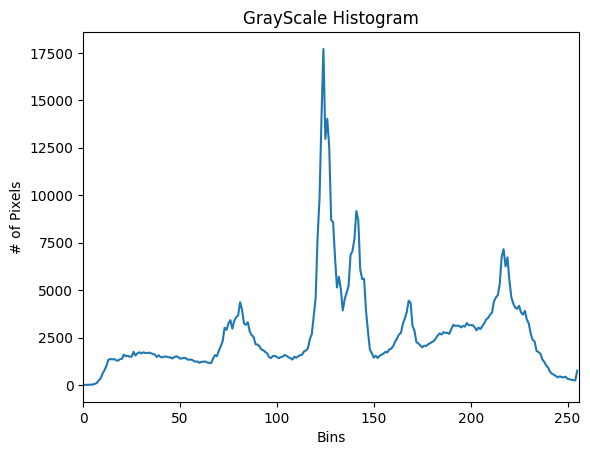

In [31]:
hist = cv.calcHist([image], [0], None, [256], [0,256])
plt.figure()
plt.title("GrayScale Histogram")
plt.xlabel("Bins")
plt.ylabel("# of Pixels")
plt.plot(hist)
plt.xlim([0,256])
plt.show()

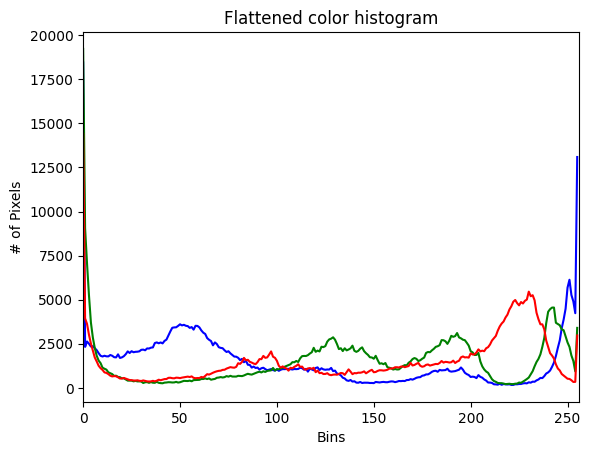

In [ ]:
colors_image = cv.imread("colors.jpg")
chans = cv.split(colors_image)
colors = ("b", "g", "r")
plt.figure()
plt.title("Flattened color histogram")
plt.xlabel("Bins")
plt.ylabel("# of Pixels")

for (chan, color) in zip(chans, colors):
    hist = cv.calcHist([chan], [0], None, [256], [0,256])
    plt.plot(hist, color=color)
    plt.xlim([0,256])
plt.show()

### Smoothing And Blurring

In [33]:
image = cv.imread("colors.jpg")
blurred = np.hstack(
    [
        cv.blur(image, (3,3)),
        cv.blur(image, (5,5)),
        cv.blur(image, (7,7))
    ]
)
cv.imshow("Blurred Images", blurred)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [35]:
blurred = np.hstack(
    [
        cv.GaussianBlur(image, (3,3),0),
        cv.GaussianBlur(image, (5,5),0),
        cv.GaussianBlur(image, (7,7),0)
    ]
)
cv.imshow("Gaussian Blurred Images", blurred)
if cv.waitKey(0):
    cv.destroyAllWindows()

In [36]:
blurred = np.hstack(
    [
        cv.medianBlur(image,3),
        cv.medianBlur(image,5),
        cv.medianBlur(image,7)
    ]
)
cv.imshow("Median Blurred Images", blurred)
if cv.waitKey(0):
    cv.destroyAllWindows()